In [1]:
import numpy as np
from scipy.interpolate import griddata
from pathlib import Path

from datetime import datetime
import os
import pandas as pd
import xarray as xr

# ------------------------------------------------------------
# Paths to directories
# ------------------------------------------------------------
postproc_dir = Path('/export/lv9/projects/dws/results/validation/benthos/')
model_output_dir = Path('/export/lv9/projects/dws/model_output/archived_runs/spinup_02/')

# ------------------------------------------------------------
# Paths to files
# ------------------------------------------------------------
topo_nc = Path('/export/lv9/projects/dws/model_input/bathymetry/topo_dws_500m.nc')

In [2]:
SIBES_data = pd.read_csv(
    "/export/lv9/projects/dws/results/validation/benthos/feeding_groups_gC_m2_ecotopes_SIBES.csv"
)
SUBES_data = pd.read_csv(
    "/export/lv9/projects/dws/results/validation/benthos/feeding_groups_gC_m2_ecotopes_SUBES.csv"
)

print("SIBES_data shape:", SIBES_data.shape)
print("SUBES_data shape:", SUBES_data.shape)

SIBES_data shape: (45893, 16)
SUBES_data shape: (1759, 15)


Found 12 monthly NetCDF files.
Observation rows in model period: 3738
Model period: 2015-01-01 00:00:00 -> 2016-01-01 00:00:00


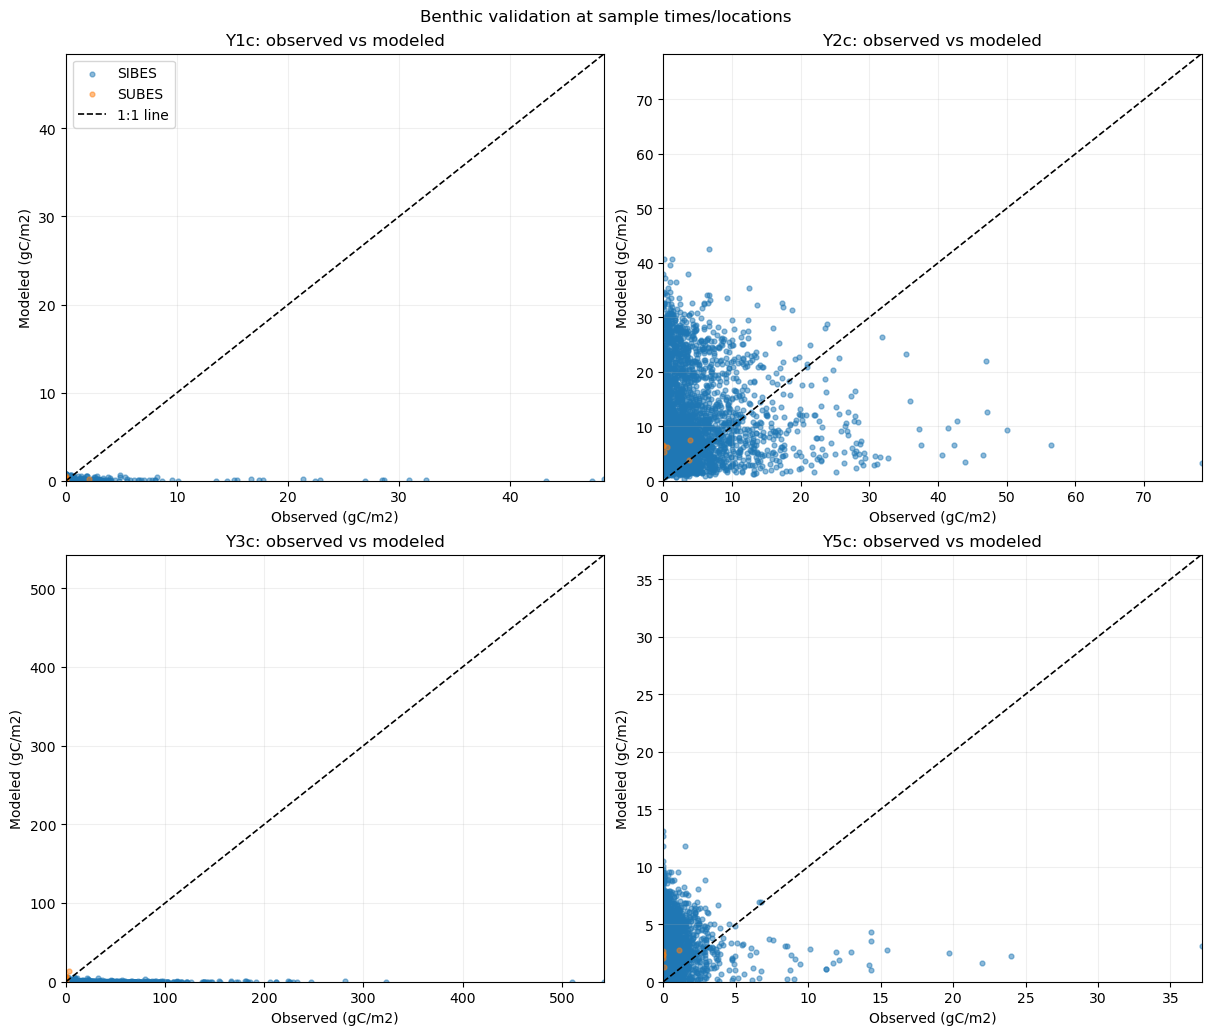

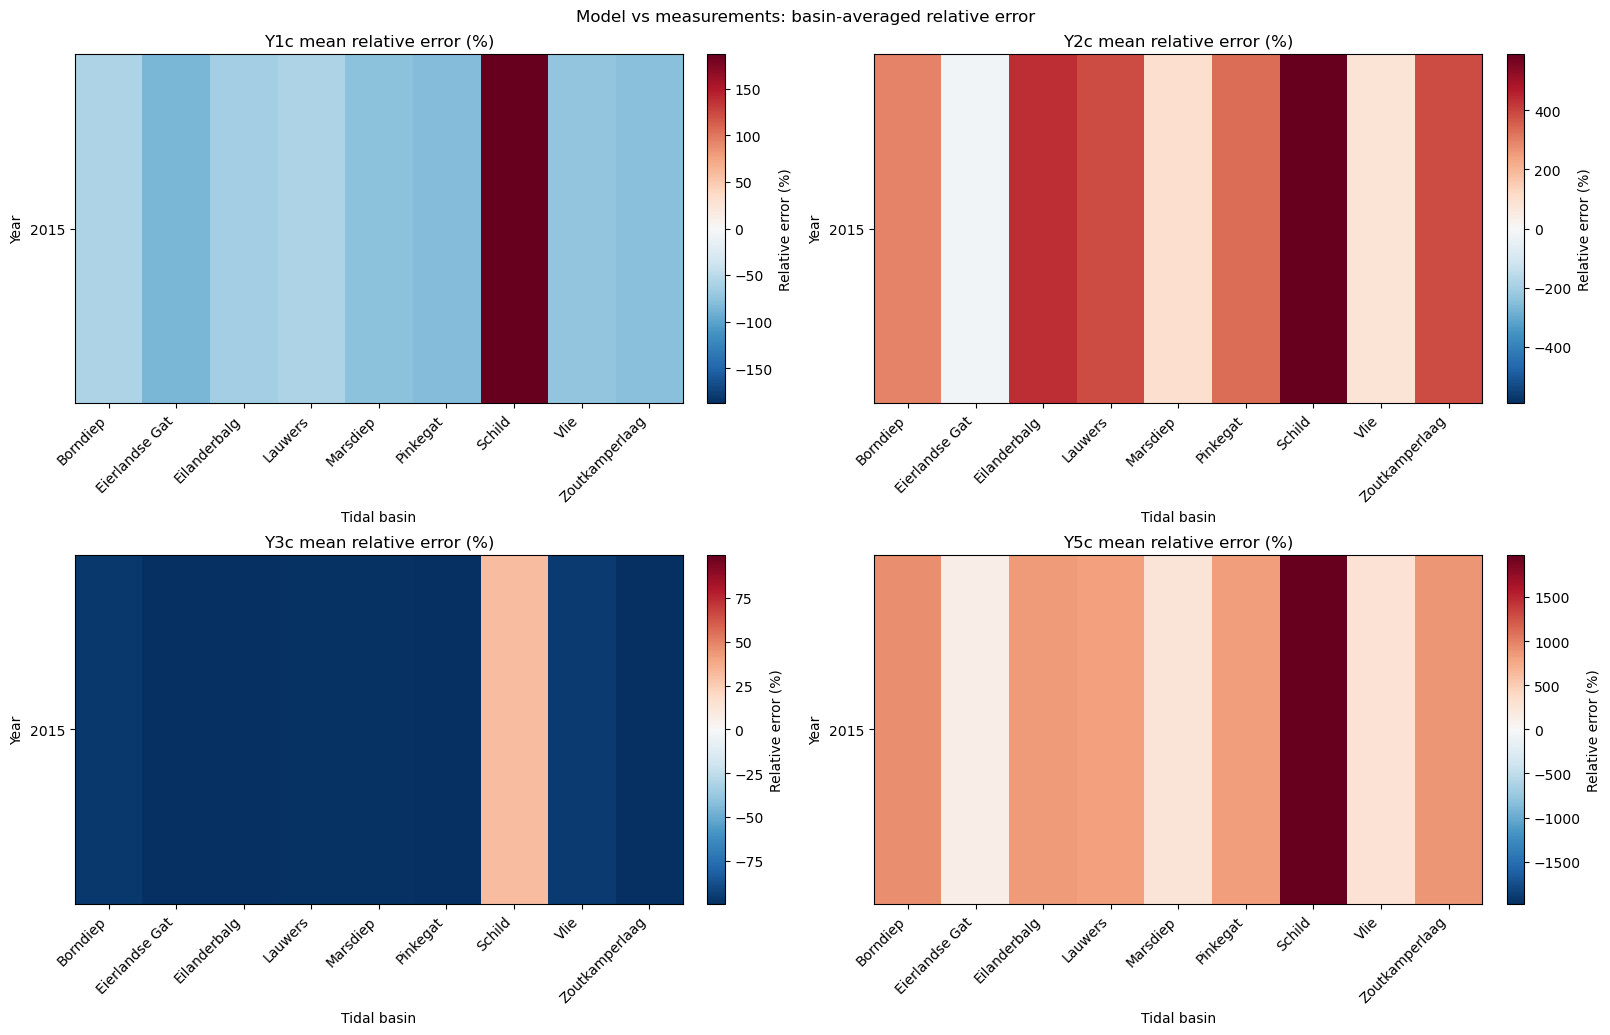

Saved scatter figure: /export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_validation_scatter_2015.png
Saved heatmap figure: /export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_validation_heatmap_relerr_2015.png
Saved collocated table: /export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_collocated_model_vs_obs_2015.csv


In [3]:
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nc_pattern = "dws_500m.3d.2015*.nc"
model_vars = {
    "Y1c": "epibenthos_Y1_c",
    "Y2c": "deposit_feeders_Y2_c",
    "Y3c": "adult_suspension_feeders_Y3_c",
    "Yy3c": "young_suspension_feeders_Yy3_c",
    "Y5c": "endobenthos_Y5_c",
}
validation_vars = ["Y1c", "Y2c", "Y3c", "Y5c"]
obs_col_for_var = {
    "Y1c": "epibenthos_Y1_c",
    "Y2c": "deposit_feeders_Y2_c",
    "Y3c": "suspension_feeders_Y3_c",
    "Y5c": "endobenthos_Y5_c",
}
obs_floor_gC_m2 = 0.05  # avoid unstable percentages when basin-year mean observed is near zero
out_dir = postproc_dir / "spinup_02"
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Build observations table (SIBES + SUBES)
# ------------------------------------------------------------
def _prep_obs(df: pd.DataFrame, source: str) -> pd.DataFrame:
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["source"] = source
    return out

obs = pd.concat(
    [_prep_obs(SIBES_data, "SIBES"), _prep_obs(SUBES_data, "SUBES")],
    ignore_index=True,
)
obs = obs.dropna(subset=["date", "x", "y", "tidal_basin_name"]).copy()

# ------------------------------------------------------------
# Open model output (all monthly files for 2015)
# Use explicit file-by-file concat to avoid duplicate-time alignment errors.
# ------------------------------------------------------------
nc_files = sorted(model_output_dir.glob(nc_pattern))
if len(nc_files) == 0:
    raise FileNotFoundError(f"No files found in {model_output_dir} matching {nc_pattern}")

print(f"Found {len(nc_files)} monthly NetCDF files.")

needed = ["time", "lonc", "latc", *model_vars.keys()]
datasets = []
for fp in nc_files:
    dsi = xr.open_dataset(fp, chunks={"time": 32})
    missing_i = [v for v in needed if v not in dsi.variables and v not in dsi.coords]
    if missing_i:
        raise KeyError(f"{fp.name} missing required variables/coords: {missing_i}")

    dsi = dsi[needed]
    t_idx_i = pd.Index(pd.to_datetime(dsi["time"].values))
    if t_idx_i.has_duplicates:
        dsi = dsi.isel(time=~t_idx_i.duplicated())
    datasets.append(dsi)

ds = xr.concat(
    datasets,
    dim="time",
    data_vars="minimal",
    coords="minimal",
    compat="override",
    join="override",
)

ds = ds.sortby("time")
t_idx = pd.Index(pd.to_datetime(ds["time"].values))
if t_idx.has_duplicates:
    ds = ds.isel(time=~t_idx.duplicated())

model_times = pd.DatetimeIndex(pd.to_datetime(ds["time"].values))
model_t0 = model_times.min()
model_t1 = model_times.max()

# Keep only period covered by model to avoid nearest-time extrapolation.
obs = obs[(obs["date"] >= model_t0) & (obs["date"] <= model_t1)].copy()
if obs.empty:
    raise ValueError("No observation rows fall within model time coverage.")

print(f"Observation rows in model period: {len(obs)}")
print(f"Model period: {model_t0} -> {model_t1}")

# ------------------------------------------------------------
# Nearest-neighbor collocation in horizontal space
# ------------------------------------------------------------
lon2d = ds["lonc"].values
lat2d = ds["latc"].values
mask = np.isfinite(lon2d) & np.isfinite(lat2d)

flat_lon = lon2d[mask]
flat_lat = lat2d[mask]
flat_iy, flat_ix = np.where(mask)

tree = cKDTree(np.column_stack([flat_lon, flat_lat]))
obs_coords = np.column_stack([obs["x"].to_numpy(), obs["y"].to_numpy()])
_, nn_idx = tree.query(obs_coords, k=1)

obs["iy"] = flat_iy[nn_idx]
obs["ix"] = flat_ix[nn_idx]

# ------------------------------------------------------------
# Nearest-neighbor collocation in time
# ------------------------------------------------------------
mt = model_times.to_numpy(dtype="datetime64[ns]")
ot = obs["date"].to_numpy(dtype="datetime64[ns]")

right = np.searchsorted(mt, ot, side="left")
left = np.clip(right - 1, 0, len(mt) - 1)
right = np.clip(right, 0, len(mt) - 1)

left_diff = np.abs(ot - mt[left])
right_diff = np.abs(mt[right] - ot)
use_right = right_diff < left_diff
obs["it"] = np.where(use_right, right, left)
obs["model_time"] = model_times.take(obs["it"].to_numpy())
obs["year"] = obs["date"].dt.year

def _model_da_for_var(ds: xr.Dataset, mvar: str) -> xr.DataArray:
    # For suspension feeders compare against total adults+young in the model.
    if mvar == "Y3c":
        if "Yy3c" not in ds.variables:
            raise KeyError("Yy3c is required to compare suspension feeders (Y3c + Yy3c).")
        return ds["Y3c"] + ds["Yy3c"]
    return ds[mvar]

# ------------------------------------------------------------
# Extract model values at collocated points
# Model units are mgC/m2, convert to gC/m2 to match observations.
# ------------------------------------------------------------
it = xr.DataArray(obs["it"].to_numpy(), dims="obs")
iy = xr.DataArray(obs["iy"].to_numpy(), dims="obs")
ix = xr.DataArray(obs["ix"].to_numpy(), dims="obs")

for mvar in validation_vars:
    ocol = obs_col_for_var[mvar]
    vals_model_gC_m2 = (_model_da_for_var(ds, mvar) / 1000.0).isel(time=it, yc=iy, xc=ix).values
    obs[f"{mvar}_model_gC_m2"] = vals_model_gC_m2
    obs[f"{mvar}_obs_gC_m2"] = obs[ocol].to_numpy()

# ------------------------------------------------------------
# Scatter plots: measured vs modeled + 1:1 line
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.ravel()

for ax, mvar in zip(axes, validation_vars):
    x_obs = obs[f"{mvar}_obs_gC_m2"].to_numpy()
    y_mod = obs[f"{mvar}_model_gC_m2"].to_numpy()

    valid = np.isfinite(x_obs) & np.isfinite(y_mod)
    x_obs = x_obs[valid]
    y_mod = y_mod[valid]
    src = obs.loc[valid, "source"].to_numpy()

    for source_name, color in [("SIBES", "tab:blue"), ("SUBES", "tab:orange")]:
        sel = src == source_name
        if np.any(sel):
            ax.scatter(x_obs[sel], y_mod[sel], s=12, alpha=0.5, label=source_name, color=color)

    if len(x_obs) > 0:
        lim_min = np.nanmin([x_obs.min(), y_mod.min()])
        lim_max = np.nanmax([x_obs.max(), y_mod.max()])
        if np.isfinite(lim_min) and np.isfinite(lim_max) and lim_max > lim_min:
            ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1.2, label="1:1 line")
            ax.set_xlim(lim_min, lim_max)
            ax.set_ylim(lim_min, lim_max)

    ax.set_title(f"{mvar}: observed vs modeled")
    ax.set_xlabel("Observed (gC/m2)")
    ax.set_ylabel("Modeled (gC/m2)")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles, labels, loc="best")

plt.suptitle("Benthic validation at sample times/locations", y=1.02)
scatter_png = out_dir / "benthic_validation_scatter_2015.png"
fig.savefig(scatter_png, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Heatmaps: mean relative error (%) by year (rows) and tidal basin (cols)
# Computed from basin-year means:
#   rel_err_pct = (mean_model - mean_observed) / mean_observed * 100
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ax, mvar in zip(axes, validation_vars):
    obs_col = f"{mvar}_obs_gC_m2"
    mod_col = f"{mvar}_model_gC_m2"

    work = obs[["year", "tidal_basin_name", obs_col, mod_col]].copy()
    work = work[np.isfinite(work[obs_col]) & np.isfinite(work[mod_col])]

    grouped = (
        work.groupby(["year", "tidal_basin_name"], observed=False)
        .agg(mean_obs=(obs_col, "mean"), mean_mod=(mod_col, "mean"), n=(obs_col, "size"))
        .reset_index()
    )

    grouped["rel_err_pct"] = np.nan
    stable = grouped["mean_obs"].abs() >= obs_floor_gC_m2
    grouped.loc[stable, "rel_err_pct"] = (
        (grouped.loc[stable, "mean_mod"] - grouped.loc[stable, "mean_obs"])
        / grouped.loc[stable, "mean_obs"]
        * 100.0
    )

    table = (
        grouped.pivot(index="year", columns="tidal_basin_name", values="rel_err_pct")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    if table.size == 0:
        ax.set_axis_off()
        ax.set_title(f"{mvar}: no valid values")
        continue

    vals = table.values[np.isfinite(table.values)]
    vmax = max(10.0, np.nanpercentile(np.abs(vals), 95)) if vals.size else 100.0

    img = ax.imshow(table.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index.astype(int))
    ax.set_title(f"{mvar} mean relative error (%)")
    ax.set_xlabel("Tidal basin")
    ax.set_ylabel("Year")

    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Relative error (%)")

plt.suptitle("Model vs measurements: basin-averaged relative error", y=1.02)
heatmap_png = out_dir / "benthic_validation_heatmap_relerr_2015.png"
fig.savefig(heatmap_png, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save collocated table for follow-up analysis
# ------------------------------------------------------------
out_csv = out_dir / "benthic_collocated_model_vs_obs_2015.csv"
obs.to_csv(out_csv, index=False)
print(f"Saved scatter figure: {scatter_png}")
print(f"Saved heatmap figure: {heatmap_png}")
print(f"Saved collocated table: {out_csv}")

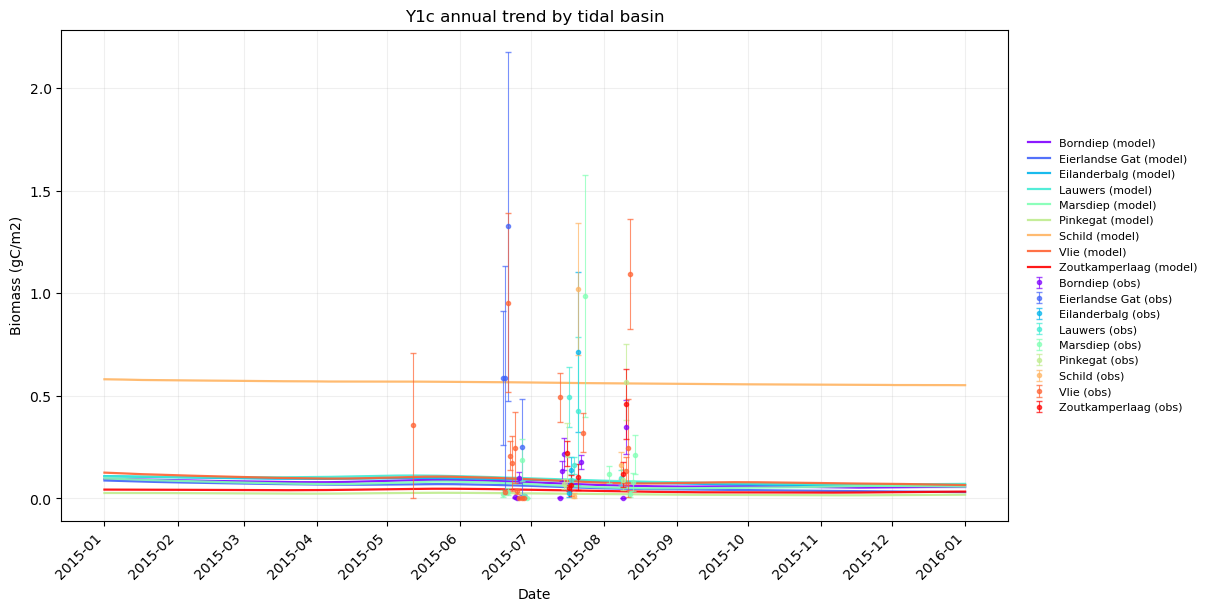

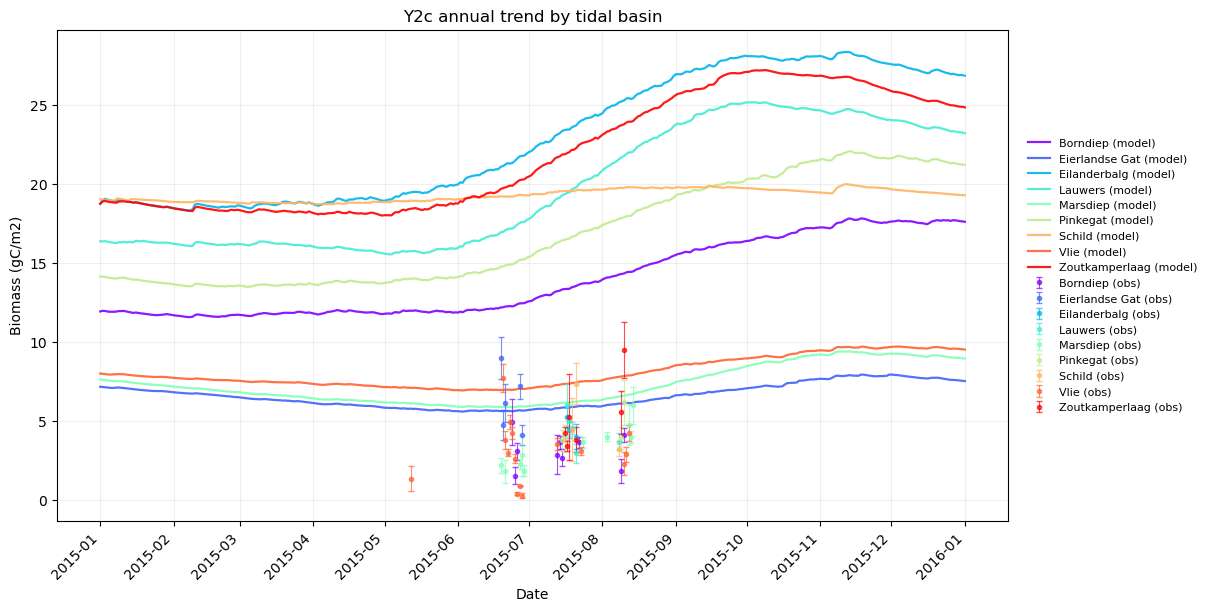

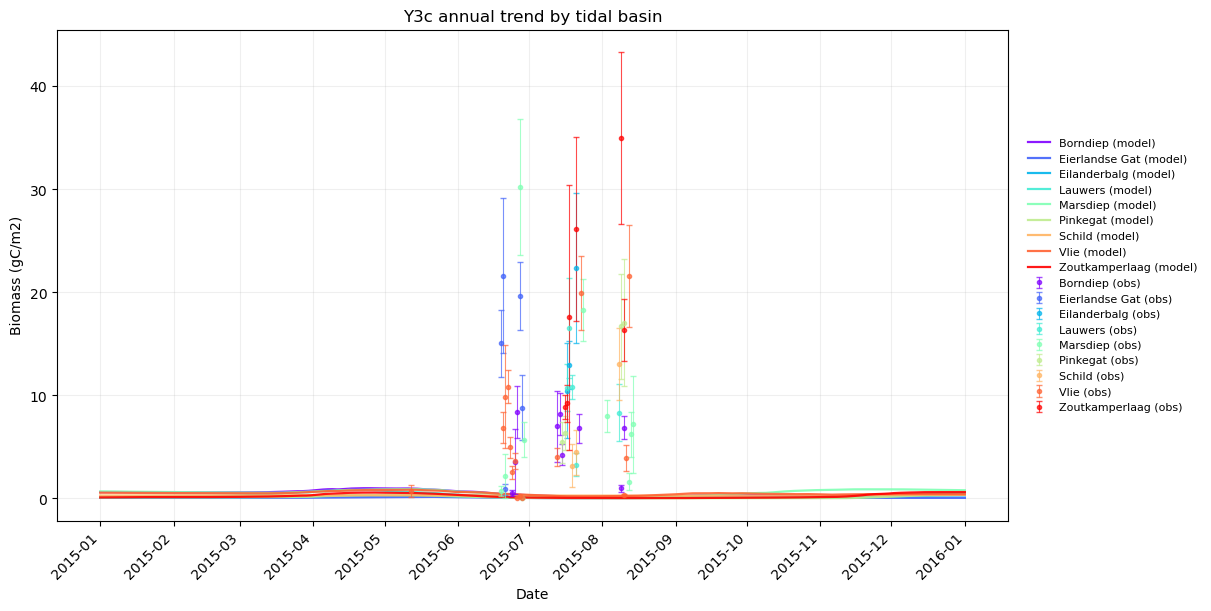

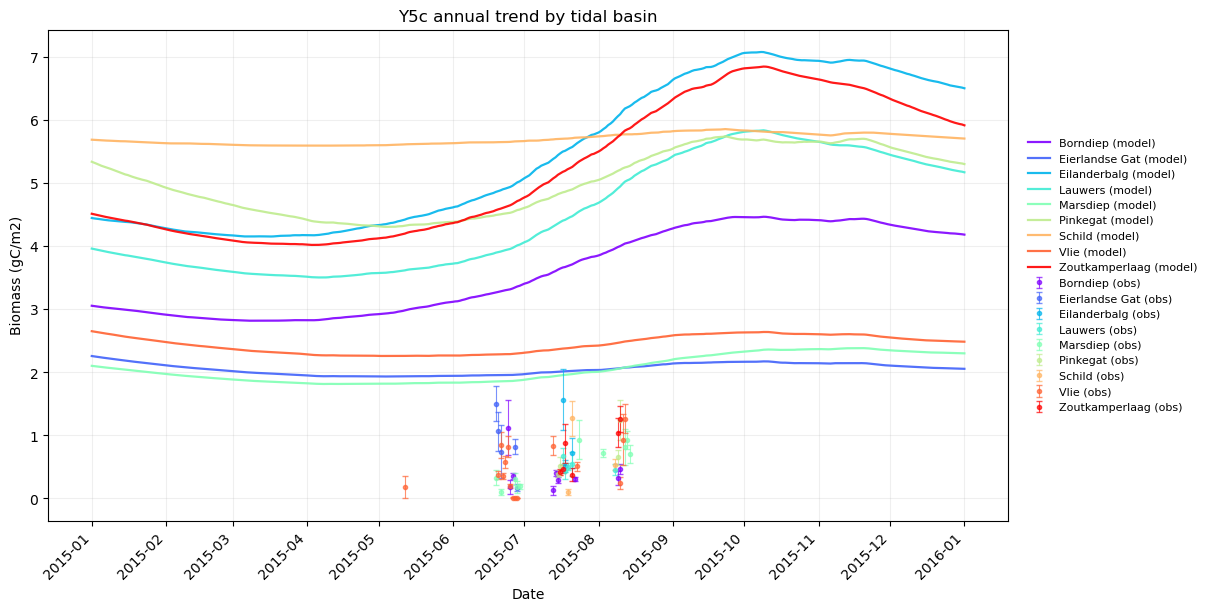

Saved trend figures:
/export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_validation_trend_Y1c_2015.png
/export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_validation_trend_Y2c_2015.png
/export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_validation_trend_Y3c_2015.png
/export/lv9/projects/dws/results/validation/benthos/spinup_02/benthic_validation_trend_Y5c_2015.png


In [4]:
import matplotlib.dates as mdates

# ------------------------------------------------------------
# Trend plots by tidal basin (one figure per feeding group)
# Model: daily basin-mean trend from model values sampled at basin stations.
# Obs: date-basin mean with standard error bars.
# ------------------------------------------------------------

# Use basin list present in collocated data during model period.
basins = sorted(obs["tidal_basin_name"].dropna().unique().tolist())
if len(basins) == 0:
    raise ValueError("No tidal basins found in collocated observations.")

cmap = plt.get_cmap("rainbow", len(basins))
basin_colors = {b: cmap(i) for i, b in enumerate(basins)}

trend_pngs = []

# Unique model sample points per basin from collocated station-grid pairs.
# These points define the spatial support for basin-mean modeled trends.
basin_points = (
    obs[["tidal_basin_name", "iy", "ix"]]
    .dropna(subset=["tidal_basin_name", "iy", "ix"])
    .drop_duplicates()
)

for mvar in validation_vars:
    ocol = obs_col_for_var[mvar]
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

    da_model = _model_da_for_var(ds, mvar) / 1000.0  # mgC/m2 -> gC/m2

    # Plot modeled basin trends (daily time series)
    for basin in basins:
        pts = basin_points[basin_points["tidal_basin_name"] == basin]
        if pts.empty:
            continue

        iy_b = xr.DataArray(pts["iy"].astype(int).to_numpy(), dims="p")
        ix_b = xr.DataArray(pts["ix"].astype(int).to_numpy(), dims="p")

        trend = da_model.isel(yc=iy_b, xc=ix_b).mean(dim="p", skipna=True)
        ax.plot(
            model_times,
            trend.values,
            color=basin_colors[basin],
            lw=1.6,
            alpha=0.9,
            label=f"{basin} (model)",
        )

    # Overlay observations grouped by date and basin with standard error bars
    obs_grp = (
        obs[["date", "tidal_basin_name", ocol]]
        .dropna(subset=["date", "tidal_basin_name", ocol])
        .groupby(["tidal_basin_name", "date"], observed=False)[ocol]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    obs_grp["se"] = obs_grp["std"] / np.sqrt(obs_grp["count"].clip(lower=1))
    obs_grp["se"] = obs_grp["se"].fillna(0.0)

    for basin in basins:
        tmp = obs_grp[obs_grp["tidal_basin_name"] == basin].sort_values("date")
        if tmp.empty:
            continue
        ax.errorbar(
            tmp["date"],
            tmp["mean"],
            yerr=tmp["se"],
            fmt="o",
            ms=3,
            capsize=2,
            elinewidth=0.8,
            color=basin_colors[basin],
            alpha=0.7,
            label=f"{basin} (obs)",
        )

    ax.set_title(f"{mvar} annual trend by tidal basin")
    ax.set_xlabel("Date")
    ax.set_ylabel("Biomass (gC/m2)")
    ax.grid(True, alpha=0.2)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Keep one legend entry per basin (model/obs) while placing outside the plot area.
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(
        uniq.values(),
        uniq.keys(),
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=8,
        frameon=False,
    )

    out_png = out_dir / f"benthic_validation_trend_{mvar}_2015.png"
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    trend_pngs.append(out_png)
    plt.show()

print("Saved trend figures:")
for p in trend_pngs:
    print(p)